## Triangulation

In [73]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import itertools

# seeds for Gulf triangulation : 42, 1, 11
# seeds for Laurentienne triangulation : 13, 666

def compute_coordinates_least_squares(distances, seed=42):
    """
    Computes 2D coordinates for plants using nonlinear least squares.
    :param distances: dict with (plant1, plant2) as keys and distance as values
    :return: dict {plant_id: (x, y)}
    """

    # Set seed for reproducibility
    np.random.seed(seed)
    
    # Get unique plant IDs
    plants = sorted(set(p for pair in distances.keys() for p in pair))
    num_plants = len(plants)

    # Assign fixed reference points
    fixed_points = {plants[0]: (0, 0), plants[1]: (distances.get((plants[0], plants[1]), 50), 0)}
    
    # Initial guess: Spread remaining points randomly
    init_coords = np.random.rand((num_plants - 2) * 2) * 100

    def error_function(variables):
        """
        Computes errors between calculated and given distances.
        """
        coords = fixed_points.copy()
        idx = 0
        for p in plants[2:]:
            coords[p] = (variables[idx], variables[idx + 1])
            idx += 2
        
        errors = []
        for (p1, p2), d in distances.items():
            if p1 in coords and p2 in coords:
                x1, y1 = coords[p1]
                x2, y2 = coords[p2]
                dist_computed = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
                errors.append(dist_computed - d)

        return errors

    # Solve using least squares
    result = least_squares(error_function, init_coords, method='lm')

    # Extract final coordinates
    coords = fixed_points.copy()
    idx = 0
    for p in plants[2:]:
        coords[p] = (result.x[idx], result.x[idx + 1])
        idx += 2
    
    return coords

def compute_all_distances(plant_coords):
    """
    Computes the Euclidean distances between all pairs of plants.
    
    :param plant_coords: dict {plant_id: (x, y)}
    :return: dict { (plant1, plant2): distance }
    """
    distances = {}
    plant_ids = sorted(plant_coords.keys())
    
    for p1, p2 in itertools.combinations(plant_ids, 2):
        x1, y1 = plant_coords[p1]
        x2, y2 = plant_coords[p2]
        distance = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        distances[(p1, p2)] = distance
    
    return distances


# Example input dictionary (modify as needed)
distances = {
    (1, 2): 40,
    (1, 3): 100,
    (2, 3): 60,
    (1, 4): 140,
    (2, 4): 100,
    (3, 4): 110,
    (5, 1): 110,
    (5, 3): 165,
    (5, 2): 145,
    (6, 8): 165,
    (6, 2): 165,
    (6, 1): 170,
    (6, 5): 90,
    (7, 6): 65,
    (7, 5): 130,
    (7, 1): 187,
    (7, 2): 175,
    (7, 3): 150,
    (7, 4): 256,
    (6, 4): 270,
    (3, 8): 37,
    (2, 8): 46,
    (1, 8): 87,
    (6, 8): 140,
    (8, 5): 130
}

distances = {
    (3, 6): 50,
    (7, 6): 275,
    (7, 3): 300,
    (7, 1): 180,
    (1, 6): 290,
    (1, 3): 285
}

plant_common_names = {
    'Amelanchier canadensis': 'Serviceberry',
    'Dryopteris filix-mas': 'Male Fern',
    'Lysimachia ciliata': 'Fringed Loosestrife',
    'Onoclea sensibilis': 'Sensitive Fern',
    'Diervilla lonicera': 'Bush Honeysuckle',
    'Carex intumescens': 'Bladder Sedge',
    'Vaccinium angustifolium': 'Lowbush Blueberry',
    'Symphiotrum novi-belgii': 'New York Aster'
}

plant_common_names = {
    'Acer rubrum': 'Red Maple',
    'Dryopteris mas': 'Male Fern',
    'Geum rivale': 'Water Avens',
    'Myrica gale': 'Sweet Gale'
}

# Ensure plant numbers match the correct names
plant_ids = sorted(set(p for pair in distances.keys() for p in pair))  # Extract unique plant IDs
id_to_name = {plant_ids[i]: list(plant_common_names.keys())[i] for i in range(len(plant_ids))}  # Map IDs to names

# Compute coordinates
plant_coords = compute_coordinates_least_squares(distances, seed=666)

# Compute distances from derived coordinates
computed_distances = compute_all_distances(plant_coords)

## Interactive plot

In [63]:
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt




# Use Matplotlib’s Set2 colormap to assign a color for each plant
colors = plt.get_cmap("Set2").colors
plant_colors = {
    plant: f"rgba({int(c[0]*255)},{int(c[1]*255)},{int(c[2]*255)},1)"
    for plant, c in zip(plant_ids, colors)
}

# ========================================
# ------ Build the Figure  ---------------
# ========================================

fig = go.Figure()

# 1. Add marker traces for each plant (always visible).
#    The legend shows the plant’s common name.
for plant in plant_ids:
    x, y = plant_coords[plant]
    common_name = plant_common_names[id_to_name[plant]]
    fig.add_trace(go.Scatter(
        x=[x], y=[y],
        mode='markers+text',
        marker=dict(size=30, color=plant_colors[plant]),
        text=[plant],              # or use a plant number/ID if preferred
        textposition='top center',
        name=common_name,          # legend label (common name)
        showlegend=True,
        textfont=dict(size=16)     # increase legend label size
    ))

# 2. For each plant, add connection traces for all its connections.
#    (Each plant gets one trace for the dashed lines and one for the midpoint labels.)
#    Note: A connection (line between two plants) will be drawn twice
#          (once for each endpoint) if both plants are toggled on.
for plant in plant_ids:
    common_name = plant_common_names[id_to_name[plant]]
    line_x = []
    line_y = []
    text_x = []
    text_y = []
    text_labels = []
    
    # Loop through all computed connections and pick those that involve this plant.
    for (p1, p2), d in computed_distances.items():
        if plant in (p1, p2):
            x1, y1 = plant_coords[p1]
            x2, y2 = plant_coords[p2]
            # Add coordinates for the dashed line (None creates a break between segments)
            line_x.extend([x1, x2, None])
            line_y.extend([y1, y2, None])
            # Compute midpoint for the distance label
            mid_x = (x1 + x2) / 2
            mid_y = (y1 + y2) / 2
            text_x.append(mid_x)
            text_y.append(mid_y)
            text_labels.append(f"{d:.1f} cm")
    
    if line_x:  # only add if there are connections for this plant
        # Dashed line trace (initially hidden)
        fig.add_trace(go.Scatter(
            x=line_x, y=line_y,
            mode='lines',
            line=dict(dash='dash', color='black', width=2),
            showlegend=False,
            visible=False  # initially hidden
            
        ))
        # Distance label trace (initially hidden)
        fig.add_trace(go.Scatter(
            x=text_x, y=text_y,
            mode='markers+text',  # Use both markers and text
            marker=dict(size=40, color='white', symbol='square'),  # White square background
            text=text_labels,
            textposition='middle center',
            showlegend=False,
            visible=False,
            textfont=dict(size=16, color='black', family='Arial'),
        ))

# ---------------------------------------
# 3. Add update-menu buttons to toggle connections.
#
#    In the final figure the first 8 traces are the markers,
#    and for each plant there are 2 additional connection traces.
#    For plant i the connection traces have indices 8+2*i and 8+2*i+1.
# ---------------------------------------

# Create an initial visibility list:
# - Markers (first 8 traces): always True.
# - All connection traces: initially False.
n_markers = len(plant_ids)
n_connections = (len(fig.data) - n_markers)  # should be 2 per plant
initial_visibility = [True] * n_markers + [False] * n_connections

# Create one button per plant that shows its connection traces.
buttons = []
for i, plant in enumerate(plant_ids):
    common_name = plant_common_names[id_to_name[plant]]
    new_visibility = initial_visibility.copy()
    # The connection traces for plant i are at indices: n_markers + 2*i and n_markers + 2*i + 1.
    new_visibility[n_markers + 2 * i] = True
    new_visibility[n_markers + 2 * i + 1] = True
    buttons.append(dict(
        label=f"Show {common_name} connections",
        method="update",
        args=[{"visible": new_visibility}]
    ))

# Add a reset button to hide all connections.
buttons.append(dict(
    label="Reset connections",
    method="update",
    args=[{"visible": initial_visibility}]
))

# Place the update menu (dropdown) on the side.
fig.update_layout(
    title=dict(
        text='<b>Plant Locations in Laurentian Forest</b>',  # Bold title with HTML
        font=dict(size=24, color='black', family='Arial, sans-serif')
    ),
    xaxis_title='X Coordinate',
    yaxis_title='Y Coordinate',
    template='plotly_white',
    legend=dict(
        font=dict(size=16)  # Increase legend font size here
    ),
    updatemenus=[{
        "buttons": buttons,
        "direction": "down",
        "showactive": True,
        "x": 1.15,
        "y": 0.5,
        "xanchor": "left",
        "yanchor": "middle"
    }]
)


# Save the figure as HTML and display it.
pio.write_html(fig, 'interactive_plant_plot_laurentienne.html')
fig.show()


## Non-interactive plot with all connexions

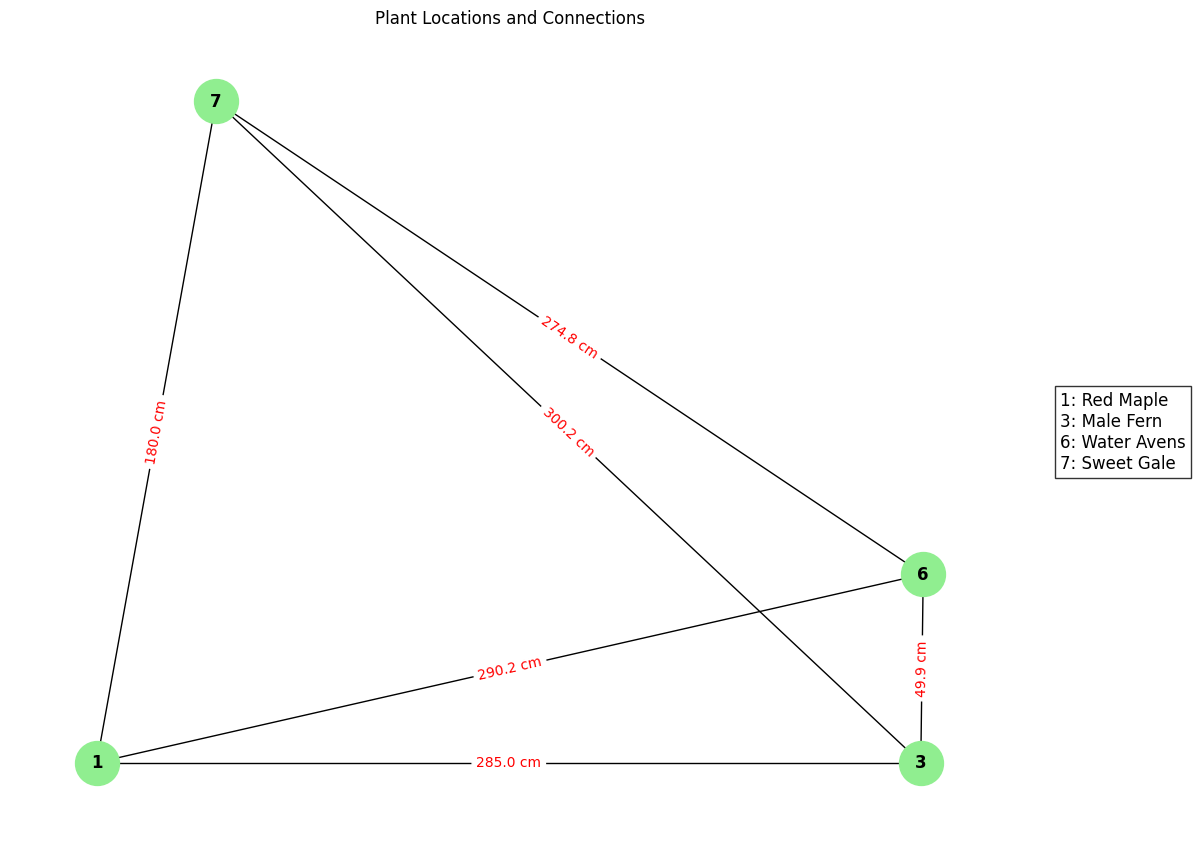

In [74]:
import matplotlib.pyplot as plt
import networkx as nx

# Create graph
G = nx.Graph()
for plant, coord in plant_coords.items():
    G.add_node(plant, pos=coord)

for (p1, p2), dist in computed_distances.items():
    G.add_edge(p1, p2, weight=dist)

# Plot
plt.figure(figsize=(10, 8))
pos = nx.get_node_attributes(G, 'pos')
labels = {edge: f"{G.edges[edge]['weight']:.1f} cm" for edge in G.edges}

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_size=1000, node_color="lightgreen", edge_color="black", font_size=12, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=10, font_color="red")

# Create legend mapping numbers to plant names
legend_labels = [f"{num}: {plant_common_names[id_to_name[num]]}" for num in plant_ids]
legend_text = "\n".join(legend_labels)

# Add legend as a text box
plt.gca().text(1.05, 0.5, legend_text, transform=plt.gca().transAxes, fontsize=12,
               verticalalignment='center', bbox=dict(facecolor='white', alpha=0.8))

plt.title("Plant Locations and Connections")
plt.show()
